# Atelier Pratique 03 — K-Means Clustering

Dans cet atelier, nous allons mettre en pratique l'algorithme **K-Means** 
sur un dataset réel issu de Kaggle : **Mall Customers**.
L'objectif est de segmenter les clients d'un centre commercial en groupes 
homogènes selon leur revenu annuel et leur score de dépenses.

>  **Remarque :** L'explication théorique du K-Means (principe, 
> fonctionnement, paramètres) a déjà été traitée dans l'atelier précédent 
> **Clustering_théorique**. Cet atelier est donc entièrement consacré à la **pratique**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv('Mall_Customers.csv')

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## Pourquoi ce Dataset ?

Nous avons choisi le dataset **Mall Customers** car il est simple, propre 
et sans valeurs manquantes (200 clients, 0 valeurs nulles), ce qui nous permet 
de nous concentrer uniquement sur l'algorithme K-Means sans perdre du temps 
dans le nettoyage des données. De plus, ses variables (revenu annuel et score 
de dépenses) forment naturellement des groupes bien visibles, ce qui rend 
le résultat du clustering facile à interpréter et à visualiser.

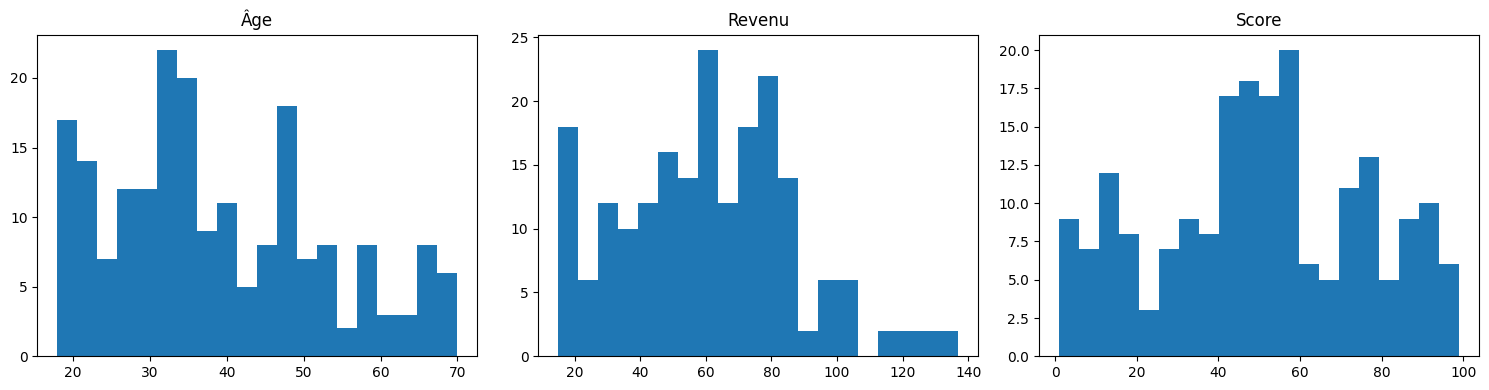

In [7]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(df['Age'], bins=20)
plt.title("Âge")

plt.subplot(1,3,2)
plt.hist(df['Annual Income (k$)'], bins=20)
plt.title("Revenu")

plt.subplot(1,3,3)
plt.hist(df['Spending Score (1-100)'], bins=20)
plt.title("Score")
plt.tight_layout()

plt.show()

Nous avons utilisé des histogrammes car nos variables sont numériques continues. L’objectif est d’analyser la distribution des données avant d’appliquer le clustering. Une courbe n’est pas adaptée car il n’y a pas d’ordre temporel, et un diagramme en barres convient plutôt aux variables catégorielles.

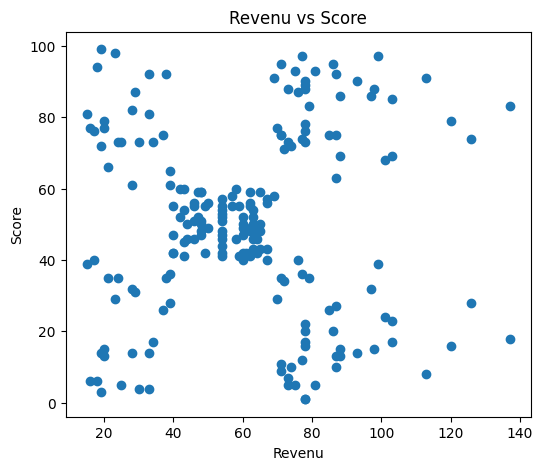

In [8]:
plt.figure(figsize=(6,5))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel('Revenu')
plt.ylabel('Score')
plt.title('Revenu vs Score')
plt.show()


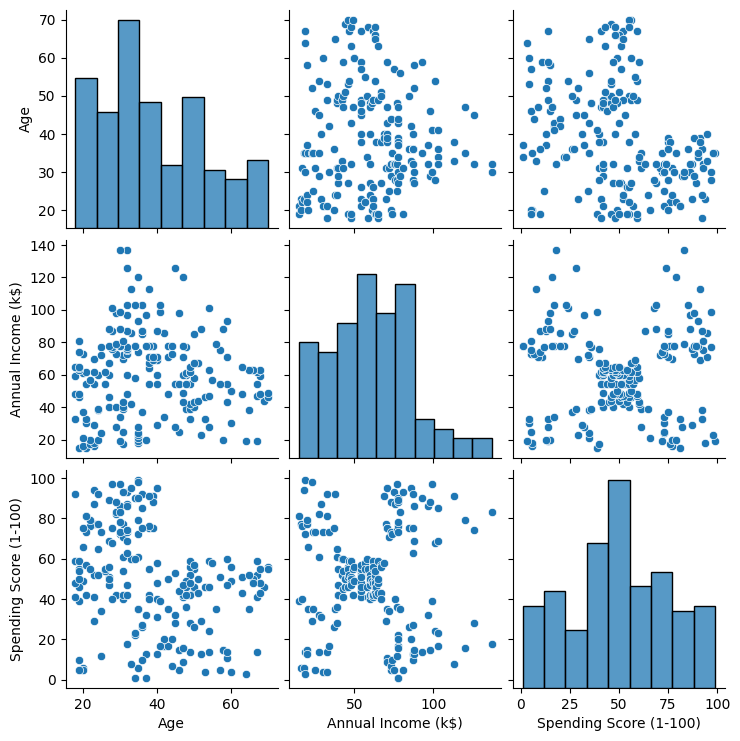

In [16]:
import seaborn as sns
sns.pairplot(df[['Age','Annual Income (k$)','Spending Score (1-100)']])
plt.show()


K-Means n’est pas une méthode de prédiction.
C’est une méthode de clustering (apprentissage non supervisé).
il regroupe les clients similaires.

### Étapes pour appliquer K-Means

1️⃣ Sélection des variables

In [37]:
X = df[[ 'Annual Income (k$)', 'Spending Score (1-100)']]


2️⃣ Appliquer la Standardisation

In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Pourquoi Standariser ?

K-Means utilise la distance euclidienne.
Comme nos variables ont des échelles différentes, nous appliquons une standardisation afin de donner la même importance à chaque variable.

4️⃣ le principe de K-Means

Étapes de l’algorithme :

1.Choisir k

2.Initialiser k centroïdes aléatoirement

3.Assigner chaque point au centre le plus proche

4.Recalculer les centres

5.Répéter jusqu’à convergence

In [39]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)


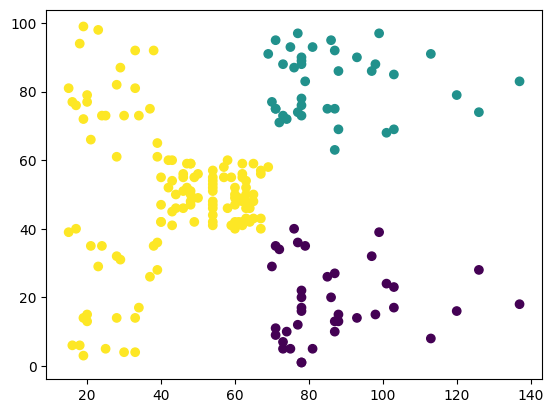

In [40]:
plt.scatter(df['Annual Income (k$)'], 
            df['Spending Score (1-100)'], 
            c=df['Cluster'])

5️⃣ La fonction de coût de K-Means

L’algorithme K-Means cherche à regrouper les données en minimisant une fonction de coût appelée <font size="4">inertia</font>  .

Mathématiquement, la fonction de coût est définie par :
                                       
                                       

$$J = \sum_{i=1}^{n} \|x_i - \mu\|^2$$

$$\text{Inertia} = d(P_1, C_1)^2 + d(P_2, C_1)^2 + d(P_3, C_2)^2 + d(P_4, C_2)^2 + \dots$$

où :

𝑥 représente un point du dataset

𝜇 représente le centroïde du cluster


$$\|x - \mu\|^2$$

est la distance euclidienne au carré entre le point et son centre

K-Means cherche à minimiser la somme des distances au carré entre chaque point et le centroïde de son cluster.
L’objectif de l’algorithme est donc de trouver les positions des centroïdes qui rendent cette somme minimale.

![alt text](image.png)

👉 Lorsque le nombre de clusters k augmente, l’inertia diminue toujours.

6️⃣ La méthode du coude (Elbow Method)

Comme l’inertia diminue toujours lorsque le nombre de clusters 
𝑘
k augmente, il est nécessaire d’utiliser une méthode permettant de déterminer un nombre optimal de clusters.

Principe

Lorsque l’on augmente 𝑘:

L’inertia diminue fortement au début Puis la diminution devient de plus en plus faible

Graphiquement, la courbe prend la forme d’un bras plié. Le point où la pente change brusquement est appelé le coude.

Ce point correspond au meilleur compromis entre :

Une bonne compacité des clusters

Un nombre raisonnable de groupes

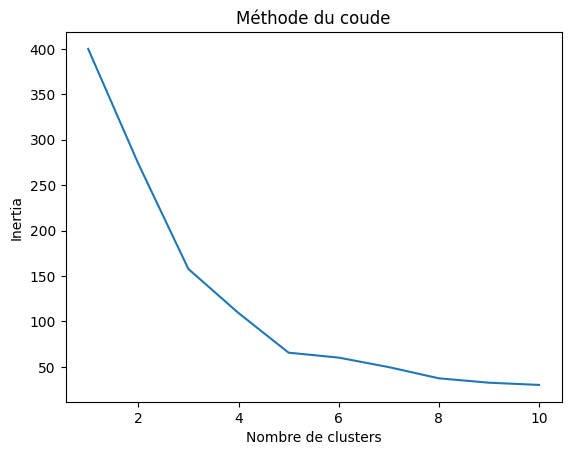

In [42]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia)
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertia")
plt.title("Méthode du coude")
plt.show()

pour une meilleur visualisation

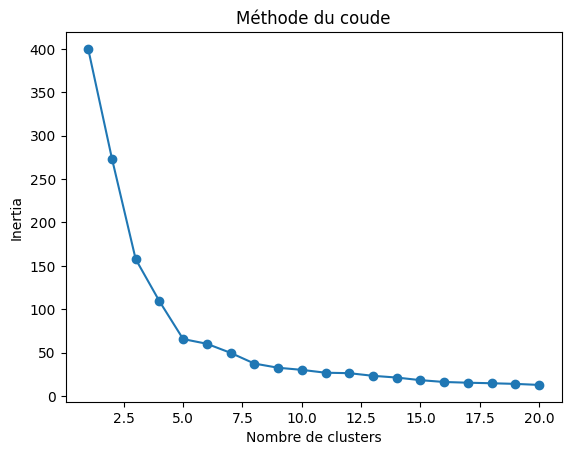

In [43]:
inertia = []

for k in range(1, 21):   # 1 à 20
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 21), inertia, marker='o')
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertia")
plt.title("Méthode du coude")
plt.show()

Le nombre de clusters k = 5 est choisi car il correspond au point du coude, où la diminution de l’inertia devient marginale. Cela indique un équilibre optimal entre précision du clustering et complexité du modèle.

In [44]:
# Application finale de K-Means avec k=5

kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

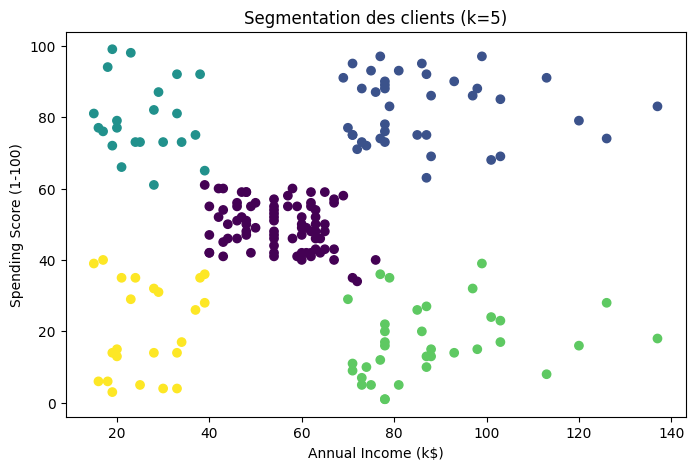

In [45]:
plt.figure(figsize=(8,5))

plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'],
            c=df['Cluster'],
            cmap='viridis')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Segmentation des clients (k=5)")
plt.show()

En résumé, nous avons utilisé K-Means pour segmenter les clients en cinq groupes distincts. La méthode du coude nous a permis de choisir un nombre optimal de clusters. Les résultats obtenus montrent une séparation cohérente des profils clients, ce qui peut être exploité pour améliorer les décisions stratégiques et commerciales.